In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def rare_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['stratify_col'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['stratify_col'].isin(valid_classes)]

    rare_df = df[~df['stratify_col'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['stratify_col'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    return train_df, tmp_df


혹시 겹치는게 있나 :  0 0 0

혹시 겹치는게 있나 :  0 0 0

혹시 겹치는게 있나 :  0 0 0

혹시 겹치는게 있나 :  0 0 0

혹시 겹치는게 있나 :  0 0 0

혹시 겹치는게 있나 :  0 0 0


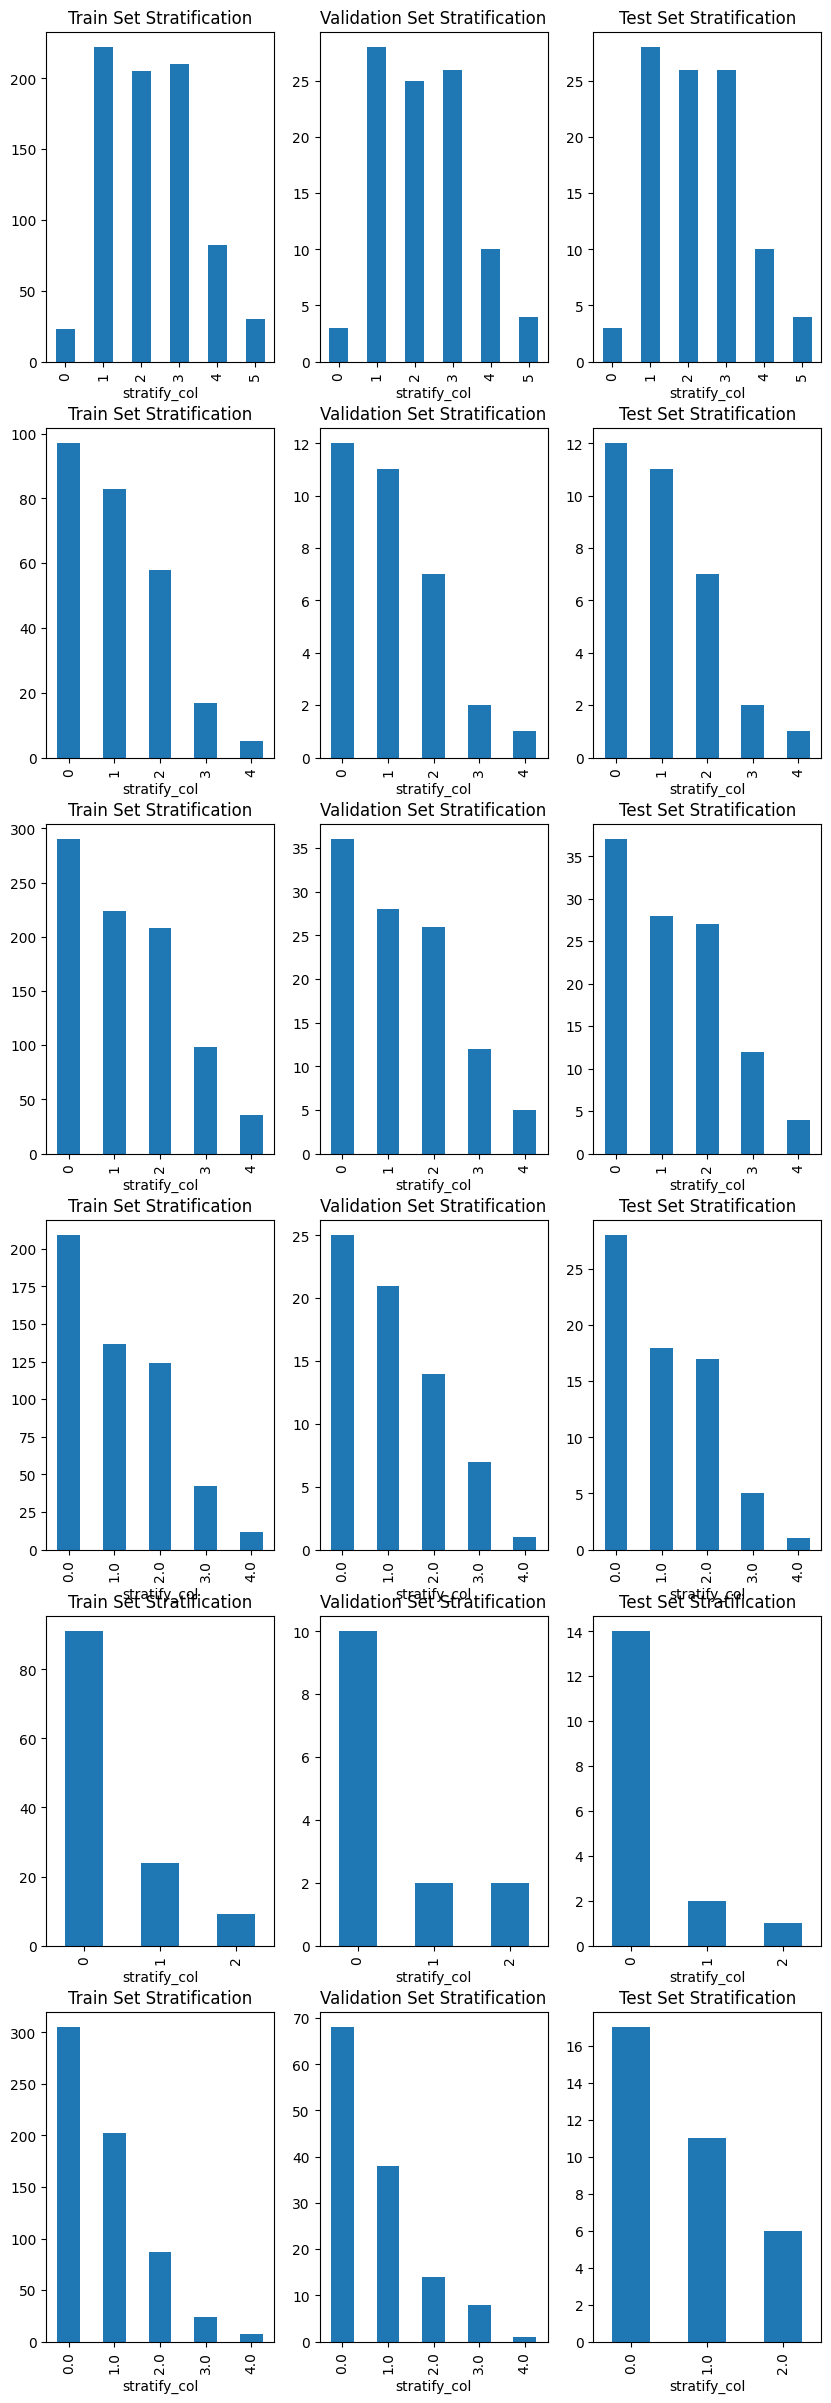

In [7]:
from sklearn.model_selection import train_test_split
import json
import os
import pandas as pd

with open('/home/work/hocheol_dir/datasets/v0.2.2_data/pigment/pig_label_paths.json', 'r') as f:
    label_paths = json.load(f)

fig, axes = plt.subplots(len(label_paths), 3, figsize=(10, 30))

for i, label_path in enumerate(label_paths):
    tr_path = os.path.join(label_path, 'pig_train.json')
    val_path = os.path.join(label_path, 'pig_val.json')
    test_path = os.path.join(label_path, 'pig_test.json')

    fold_dir = os.path.join(label_path, '5_fold')
    os.makedirs(fold_dir, exist_ok=True)

    with open(tr_path, 'r') as f:
        train_df = pd.read_json(f, dtype={'user_id': str})
    with open(val_path, 'r') as f:
        val_df = pd.read_json(f, dtype={'user_id': str})
    with open(test_path, 'r') as f:
        test_df = pd.read_json(f, dtype={'user_id': str})
        
    train_df['stratify_col'] = train_df.apply(lambda x: x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)
    val_df['stratify_col'] = val_df.apply(lambda x: x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)
    test_df['stratify_col'] = test_df.apply(lambda x: x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

    _, tr_fold = rare_split(train_df)
    _, val_fold = rare_split(val_df)
    _, test_fold = rare_split(test_df)

    # tr_fold = tr_fold[train_df.columns]
    # val_fold = val_fold[val_df.columns]
    # test_fold = test_fold[test_df.columns]

    # tr_fold = tr_fold.drop(columns=['stratify_col'])
    # val_fold = val_fold.drop(columns=['stratify_col'])
    # test_fold = test_fold.drop(columns=['stratify_col'])

    print()
    print(
        '혹시 겹치는게 있나 : ',
        len(pd.merge(tr_fold, val_fold, on='user_id', how='inner')),
        len(pd.merge(tr_fold, test_fold, on='user_id', how='inner')),
        len(pd.merge(val_fold, test_fold, on='user_id', how='inner'))
    )

    with open(os.path.join(label_path, '5_fold', 'pig_train.json'), 'w') as f:
        # json.dump(tr_fold[tr_fold.columns.difference(['stratify_col'])].to_dict(orient='records'), f, indent=2)
        json.dump(tr_fold.to_dict(orient='records'), f, indent=2)
    with open(os.path.join(label_path, '5_fold', 'pig_val.json'), 'w') as f:
        # json.dump(val_fold[val_fold.columns.difference(['stratify_col'])].to_dict(orient='records'), f, indent=2)
        json.dump(val_fold.to_dict(orient='records'), f, indent=2)
    with open(os.path.join(label_path, '5_fold', 'pig_test.json'), 'w') as f:
        # json.dump(test_fold[test_fold.columns.difference(['stratify_col'])].to_dict(orient='records'), f, indent=2)
        json.dump(test_fold.to_dict(orient='records'), f, indent=2)

    tr_fold['stratify_col'].value_counts().sort_index().plot(kind='bar', title='Train Set Stratification', ax=axes[i][0])
    val_fold['stratify_col'].value_counts().sort_index().plot(kind='bar', title='Validation Set Stratification', ax=axes[i][1])
    test_fold['stratify_col'].value_counts().sort_index().plot(kind='bar', title='Test Set Stratification', ax=axes[i][2])

plt.show()

In [8]:
train_df['stratify_col'].value_counts().sort_index() / len(train_df), tr_fold['stratify_col'].value_counts().sort_index() / len(tr_fold)

(stratify_col
 0.0    0.487836
 1.0    0.323303
 2.0    0.139245
 3.0    0.038732
 4.0    0.010883
 Name: count, dtype: float64,
 stratify_col
 0.0    0.4880
 1.0    0.3232
 2.0    0.1392
 3.0    0.0384
 4.0    0.0112
 Name: count, dtype: float64)